# Exploratory data analysis and feature extraction for logistic regression of Chagas disease from ECG data 

In [43]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import ecg_plot
import neurokit2 as nk

# SaMi-Trop

### Gathering initial statistics on SaMi-Trop data

In [44]:
sami_labels = pd.read_csv("data/samitrop_chagas_labels.csv")
sami_data = pd.read_csv("data/sami_trop.csv")
print(sami_labels.shape)
print(sami_data.shape)

(815, 2)
(1631, 7)


Number of positive cases: 815
Number of negative cases: 816


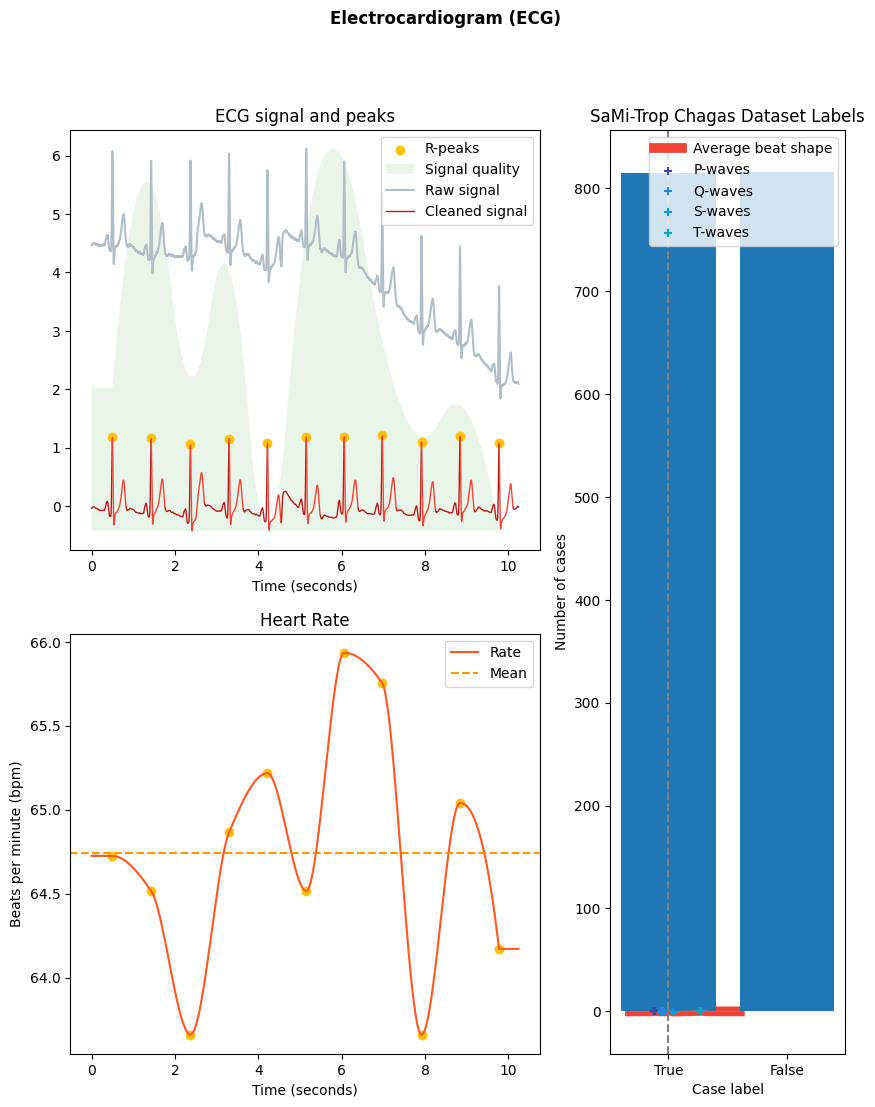

In [45]:
print(f"Number of positive cases: {len(sami_labels)}")
print(f"Number of negative cases: {len(sami_data)-len(sami_labels)}")
labels = ["True", "False"]
num_labels = [len(sami_labels), (len(sami_data)-len(sami_labels))]
plt.bar(labels, num_labels)
plt.title("SaMi-Trop Chagas Dataset Labels")
plt.ylabel("Number of cases")
plt.xlabel("Case label")
plt.show()

### Loading data for ECGs and Chagas labels

In [46]:
# File permissions must be changed to allow the file to be read
!chmod 644 "data/exams.hdf5"

In [47]:
# Reading and plotting SaMi-Trop hdf5 data
f = h5py.File('data/exams.hdf5', 'r')

st_dset = f['tracings']
st_dset.shape

(1631, 4096, 12)

In [48]:
st_data = pd.read_csv('data/sami_trop.csv')
st_data.head(10)

,exam_id,age,is_male,normal_ecg,death,timey,nn_predicted_age
0,294669,67,True,False,False,2.116020,51.093110
1,291318,65,True,False,False,3.077345,76.923935
2,247007,67,False,False,False,2.378450,61.212074
3,181629,34,False,False,False,2.676793,56.736490
4,250434,52,False,False,False,2.118782,71.822754
5,253698,67,False,False,False,2.071821,74.282010
6,253958,76,False,True,False,2.071821,87.866250
7,406936,75,False,False,False,2.080108,83.031970
8,250492,69,False,False,False,2.080108,54.031060
9,253803,53,False,True,False,2.071821,58.985962


In [49]:
# Variable to hold list of exams IDs for SaMi-Trop data
exam_id_list = st_data['exam_id']
# List of exam IDs with a positive Chagas label
pos_chagas_exams = sami_labels['exam_id'].tolist()

### Feature extraction

In [50]:
# Define dictionary object to store features 
st_dict = {"Dataset":[], "Chagas label":[], "avg_hr_12_leads":[], "avg_r_r_dist_12_leads":[]}
for i in range(1,13):
    st_dict.update([(f'L{i}_std_hr',[]), (f'L{i}_r_r_var',[]), (f'L{i}_qt_len',[])])
print("Cleared st_dict successfully!")
print(st_dict)

Cleared st_dict successfully!
{'Dataset': [], 'Chagas label': [], 'avg_hr_12_leads': [], 'avg_r_r_dist_12_leads': [], 'L1_std_hr': [], 'L1_r_r_var': [], 'L1_qt_len': [], 'L2_std_hr': [], 'L2_r_r_var': [], 'L2_qt_len': [], 'L3_std_hr': [], 'L3_r_r_var': [], 'L3_qt_len': [], 'L4_std_hr': [], 'L4_r_r_var': [], 'L4_qt_len': [], 'L5_std_hr': [], 'L5_r_r_var': [], 'L5_qt_len': [], 'L6_std_hr': [], 'L6_r_r_var': [], 'L6_qt_len': [], 'L7_std_hr': [], 'L7_r_r_var': [], 'L7_qt_len': [], 'L8_std_hr': [], 'L8_r_r_var': [], 'L8_qt_len': [], 'L9_std_hr': [], 'L9_r_r_var': [], 'L9_qt_len': [], 'L10_std_hr': [], 'L10_r_r_var': [], 'L10_qt_len': [], 'L11_std_hr': [], 'L11_r_r_var': [], 'L11_qt_len': [], 'L12_std_hr': [], 'L12_r_r_var': [], 'L12_qt_len': []}


In [51]:
def peak_dist(peak_list):
    """
    This function calculates a list of distances between ECG peaks given the type of peak and the 
    ECG indices for that peak
    
    PARAMETERS...
    - peak_list: list containing the index values for the ECG peaks (can be P, Q, R, S, or T)
    
    RETURNS...
    - List of distances between ECG peaks (NOTE: first value in list is the distance between the 
    first and second peak)
    """
    dist = []
    for i in range(1,len(peak_list)):
        dist.append(peak_list[i]-peak_list[i-1])
    return dist

In [ ]:
for i in range(len(st_dset)):
    print(f"{i}")
    patient_exam = st_dset[i].transpose()
    exam_id = exam_id_list[i]
    st_dict['Dataset'].append("SaMi-Trop")
    print(f"Exam ID: {exam_id}")
    
    if exam_id in pos_chagas_exams:
        chagas_label = True
    else:
        chagas_label = False
    
    print(f"Chagas label: {chagas_label}")
    st_dict['Chagas label'].append(chagas_label)
    
    # Lists to hold summary values for average heart rate and average R-to-R distance
    avg_hr = []
    avg_r_r_dist = []
    
    # Looping through each of the 12 ECG leads
    for j in range(1,13):
        try:
            ecg_signals, ecg_info = nk.ecg_process(patient_exam[j-1], sampling_rate=400)
        except ValueError:
            print(f"Empty vector at index: {i}")
            st_dict[f'L{j}_std_hr'].append('~')
            st_dict[f'L{j}_r_r_var'].append('~')
            st_dict[f'L{j}_qt_len'].append('~')
            
        except ZeroDivisionError:
            print(f"Divide by zero error at index: {i}")
            st_dict[f'L{j}_std_hr'].append('~')
            st_dict[f'L{j}_r_r_var'].append('~')
            st_dict[f'L{j}_qt_len'].append('~')
        else:
            avg_hr.append(np.mean(ecg_signals['ECG_Rate']))

            st_dict[f'L{j}_std_hr'].append(np.std(ecg_signals['ECG_Rate']))

            R_peaks = list(ecg_info['ECG_R_Peaks'])
            dist_R = peak_dist(R_peaks)
            st_dict[f'L{j}_r_r_var'].append(np.var(dist_R))

            # Calculating the average time between R peaks
            avg_r_r_dist.append(np.mean(dist_R))

            Q_peaks = list(ecg_info['ECG_Q_Peaks'])
            clean_Q_peaks = [x for x in Q_peaks if not np.isnan(x)]

            T_peaks = list(ecg_info['ECG_T_Peaks'])

            # Calculate lengths for QT peaks in ECG signal
            QT_length = []
            for q,t in zip(Q_peaks, T_peaks):
                # Only calculate distance where we have a valid Q and T value
                if not np.isnan(q) and not np.isnan(t):
                    QT_length.append(t-q)

            st_dict[f'L{j}_qt_len'].append(np.mean(QT_length))
    st_dict['avg_hr_12_leads'].append(np.mean(avg_hr))
    st_dict['avg_r_r_dist_12_leads'].append(np.mean(avg_r_r_dist))

In [ ]:
# Converting dictionary to a DataFrame
st_log_reg = pd.DataFrame(st_dict)

In [ ]:
# Save DataFrame to a CSV file
st_log_reg.to_csv("samitrop_dataframe_new.csv")

# CODE-15%

### Gathering initial statistics on overall CODE-15% data

In [ ]:
code15_labels = pd.read_csv("data/code15_chagas_labels.csv")
code15_labels.shape

In [ ]:
# Plotting results for CODE-15% dataset
print(f"Number of positive cases: {len(code15_labels[code15_labels["chagas"] == True])}")
print(f"Number of negative cases: {len(code15_labels[code15_labels["chagas"] == False])}")
c15_labels = ["True", "False"]
c15_num_labels = [len(code15_labels[code15_labels["chagas"] == True]), len(code15_labels[code15_labels["chagas"] == False])]
plt.bar(c15_labels, c15_num_labels)
plt.title("CODE-15% Chagas Dataset Labels")
plt.ylabel("Number of cases")
plt.xlabel("Case label")
plt.show()

### Loading data for ECGs and Chagas labels

In [2]:
# File permissions must be changed to allow the file to be read
!chmod 644 "data/exams_part1.hdf5"

In [34]:
# Reading and plotting SaMi-Trop hdf5 data
f = h5py.File('data/exams_part1.hdf5', 'r')

# Pulling ECG data from CODE-15% data
c15_dset = f['tracings']
c15_dset.shape

(20001, 4096, 12)

In [36]:
# Pull list of exam IDs from CODE-15% data
c15_exam_id_list = f['exam_id']
exam_id = c15_exam_id_list[5]
print(c15_exam_id_list.shape)

(20001,)


### Feature extraction

In [37]:
# Define dictionary object to store features 
c15_dict = {"Dataset":[], "Chagas label":[], "avg_hr_12_leads":[], "avg_r_r_dist_12_leads":[]}
for i in range(1,13):
    c15_dict.update([(f'L{i}_std_hr',[]), (f'L{i}_r_r_var',[]), (f'L{i}_qt_len',[])])
print("Cleared c15_dict successfully!")
print(c15_dict)

Cleared c15_dict successfully!
{'Dataset': [], 'Chagas label': [], 'avg_hr_12_leads': [], 'avg_r_r_dist_12_leads': [], 'L1_std_hr': [], 'L1_r_r_var': [], 'L1_qt_len': [], 'L2_std_hr': [], 'L2_r_r_var': [], 'L2_qt_len': [], 'L3_std_hr': [], 'L3_r_r_var': [], 'L3_qt_len': [], 'L4_std_hr': [], 'L4_r_r_var': [], 'L4_qt_len': [], 'L5_std_hr': [], 'L5_r_r_var': [], 'L5_qt_len': [], 'L6_std_hr': [], 'L6_r_r_var': [], 'L6_qt_len': [], 'L7_std_hr': [], 'L7_r_r_var': [], 'L7_qt_len': [], 'L8_std_hr': [], 'L8_r_r_var': [], 'L8_qt_len': [], 'L9_std_hr': [], 'L9_r_r_var': [], 'L9_qt_len': [], 'L10_std_hr': [], 'L10_r_r_var': [], 'L10_qt_len': [], 'L11_std_hr': [], 'L11_r_r_var': [], 'L11_qt_len': [], 'L12_std_hr': [], 'L12_r_r_var': [], 'L12_qt_len': []}


In [38]:
len(c15_dset)

20001

In [39]:
def peak_dist(peak_list):
    """
    This function calculates a list of distances between ECG peaks given the type of peak and the 
    ECG indices for that peak
    
    PARAMETERS...
    - peak_list: list containing the index values for the ECG peaks (can be P, Q, R, S, or T)
    
    RETURNS...
    - List of distances between ECG peaks (NOTE: first value in list is the distance between the 
    first and second peak)
    """
    dist = []
    for i in range(1,len(peak_list)):
        dist.append(peak_list[i]-peak_list[i-1])
    return dist

## Feature extraction for CODE-15% data

IMPORTANT: The feature extraction process for the CODE-15% data takes awhile, and I had to stop the code early several times to save a portion of the data to a CSV. Later I merged the CSVs together. 
The below code can be modified to extract ranges of the data by altering the overall 'for' loop to be different ranges. 

In [ ]:
# Need dataframe of code15_chagas_labels
code15_labels = pd.read_csv("data/code15_chagas_labels.csv")
# Loop through dataset and gather metrics
for i in range(len(c15_dset)):
    print(i)
    patient_exam = c15_dset[i].transpose()
    exam_id = c15_exam_id_list[i]
    c15_dict['Dataset'].append("CODE-15%")
    print(f"Exam ID: {exam_id}")
    if (code15_labels[code15_labels['exam_id'] == exam_id].empty):
        chagas_label = 'None'
    else:
        chagas_label = code15_labels[code15_labels['exam_id'] == exam_id].chagas.tolist()[0]
    print(chagas_label)
    c15_dict['Chagas label'].append(chagas_label)
    
    avg_hr = []
    avg_r_r_dist = []
    
    for j in range(1,13):
        try:
            ecg_signals, ecg_info = nk.ecg_process(patient_exam[j-1], sampling_rate=400)
        except ValueError:
            print(f"Empty vector at index: {i}")
            c15_dict[f'L{j}_std_hr'].append('~')
            c15_dict[f'L{j}_r_r_var'].append('~')
            c15_dict[f'L{j}_qt_len'].append('~')
            
        except ZeroDivisionError:
            print(f"Divide by zero error at index: {i}")
            c15_dict[f'L{j}_std_hr'].append('~')
            c15_dict[f'L{j}_r_r_var'].append('~')
            c15_dict[f'L{j}_qt_len'].append('~')
        else:
            avg_hr.append(np.mean(ecg_signals['ECG_Rate']))

            c15_dict[f'L{j}_std_hr'].append(np.std(ecg_signals['ECG_Rate']))

            R_peaks = list(ecg_info['ECG_R_Peaks'])
            dist_R = peak_dist(R_peaks)
            c15_dict[f'L{j}_r_r_var'].append(np.var(dist_R))

            # Calculating the average time between R peaks
            avg_r_r_dist.append(np.mean(dist_R))

            Q_peaks = list(ecg_info['ECG_Q_Peaks'])
            clean_Q_peaks = [x for x in Q_peaks if not np.isnan(x)]

            T_peaks = list(ecg_info['ECG_T_Peaks'])

            # Calculate lengths for QT peaks in ECG signal
            QT_length = []
            for q,t in zip(Q_peaks, T_peaks):
                # Only calculate distance where we have a valid Q and T value
                if not np.isnan(q) and not np.isnan(t):
                    QT_length.append(t-q)

            c15_dict[f'L{j}_qt_len'].append(np.mean(QT_length))
    c15_dict['avg_hr_12_leads'].append(np.mean(avg_hr))
    c15_dict['avg_r_r_dist_12_leads'].append(np.mean(avg_r_r_dist))

In [11]:
# Use to trim dictionary lists in the case of early stoppage
for key in c15_dict:
    print(f"{key}: {len(c15_dict[key])}")

Dataset: 2987
Chagas label: 2987
avg_hr_12_leads: 2987
avg_r_r_dist_12_leads: 2987
L1_std_hr: 2987
L1_r_r_var: 2987
L1_qt_len: 2987
L2_std_hr: 2987
L2_r_r_var: 2987
L2_qt_len: 2987
L3_std_hr: 2987
L3_r_r_var: 2987
L3_qt_len: 2987
L4_std_hr: 2987
L4_r_r_var: 2987
L4_qt_len: 2987
L5_std_hr: 2987
L5_r_r_var: 2987
L5_qt_len: 2987
L6_std_hr: 2987
L6_r_r_var: 2987
L6_qt_len: 2987
L7_std_hr: 2987
L7_r_r_var: 2987
L7_qt_len: 2987
L8_std_hr: 2987
L8_r_r_var: 2987
L8_qt_len: 2987
L9_std_hr: 2987
L9_r_r_var: 2987
L9_qt_len: 2987
L10_std_hr: 2987
L10_r_r_var: 2987
L10_qt_len: 2987
L11_std_hr: 2987
L11_r_r_var: 2987
L11_qt_len: 2987
L12_std_hr: 2987
L12_r_r_var: 2987
L12_qt_len: 2987


In [12]:
# Convert our dictionary to a DataFrame
c15_log_reg = pd.DataFrame(c15_dict)

In [13]:
# Preview the shape of the CODE-15% DataFrame
c15_log_reg.shape

(2987, 40)

In [ ]:
# Save the Code15 dataframe to a CSV for later use
# Can edit title of CSV file to reflect the range of data that was processed for features
c15_log_reg.to_csv("code15_part1_17014_20001_dataframe.csv")

# Additional Sections

## Plotting ECG data

In [19]:
# Pull the first ECG from the SaMi-Trop dataset
exam_test = f["tracings"][0]
# Transpose the value to simplify ECG extraction
exam_test = np.transpose(exam_test)

In [20]:
exam_test.shape

(12, 4096)

In [21]:
# Save png of all 12 leads for ECG exam
ecg_plot.plot(exam_test, sample_rate=400, title="ECG_test", columns=1)
ecg_plot.save_as_png("12_lead_ecg")

In [22]:
# Save png of first lead of ECG exam
ecg_plot.plot_1(exam_test[0], sample_rate=400, title="Lead I, ECG_test")
ecg_plot.save_as_png("lead_I_ecg")

## Testing out Neurokit2 as a solution for ECG processing

In [23]:
ecg_signals, ecg_info = nk.ecg_process(exam_test_swap[1], sampling_rate=400)
nk.ecg_plot(ecg_signals, ecg_info)

In [24]:
def peak_dist(peak_list):
    """
    This function calculates the distance between a type of Peak given the ECG indices for that peak
    
    Inputs...
    - peak_list: list containing the index values for the ECG peaks (can be P, Q, R, S, or T)
    Returns...
    - List of distances between ECG peaks (NOTE: first value in list is the distance between the 
    first and second peak)
    """
    dist = []
    for i in range(1,len(peak_list)):
        dist.append(peak_list[i]-peak_list[i-1])
    return dist

In [25]:
# Calculating the average and standard deviation of the heart rate values
avg_hr = np.mean(ecg_signals['ECG_Rate'])
std_hr = np.std(ecg_signals['ECG_Rate'])

In [26]:
# Calculating the R to R variance
R_peaks = list(ecg_info['ECG_R_Peaks'])
dist_R = peak_dist(R_peaks)
R_R_var = np.var(dist_R)
R_R_var

np.float64(18.159999999999997)

In [27]:
# Calculating the average time between R peaks
np.mean(dist_R)

np.float64(370.8)

In [28]:
# Calculating the average and standard deviation of the ECG signal data
avg_ECG = np.mean(exam_test_swap[1])
std_ECG = np.std(exam_test_swap[1])

In [29]:
# Calculating the average distance between all the peaks
P_peaks = list(ecg_info['ECG_P_Peaks'])
dist_P = peak_dist(P_peaks)

Q_peaks = list(ecg_info['ECG_Q_Peaks'])
clean_Q_peaks = [x for x in Q_peaks if not np.isnan(x)]
dist_Q = peak_dist(clean_Q_peaks)

S_peaks = list(ecg_info['ECG_S_Peaks'])
clean_S_peaks = [x for x in S_peaks if not np.isnan(x)]
dist_S = peak_dist(clean_S_peaks)

T_peaks = list(ecg_info['ECG_T_Peaks'])
dist_T = peak_dist(T_peaks)

print(f"Average distance between...")
print(f"P-peaks = {np.mean(dist_P)}")
print(f"Q-peaks = {np.mean(dist_Q)}")
print(f"R-peaks = {np.mean(dist_R)}")
print(f"S-peaks = {np.mean(dist_S)}")
print(f"T-peaks = {np.mean(dist_T)}")
print(f"----------------------------")
print(f"Total average distance between all peaks = {np.mean(dist_P + dist_Q + dist_R + dist_S + dist_T)}")

Average distance between...
P-peaks = 370.9
Q-peaks = 370.3333333333333
R-peaks = 370.8
S-peaks = 370.44444444444446
T-peaks = 371.4
----------------------------
Total average distance between all peaks = 370.7916666666667


In [30]:
# Calculate lengths for QT peaks in ECG signal
QT_length = []
for q,t in zip(Q_peaks, T_peaks):
    # Only calculate distance where we have a valid Q and T value
    if not np.isnan(q) and not np.isnan(t):
        QT_length.append(t-q)

In [31]:
QT_statistics = (np.mean(QT_length), np.max(QT_length), np.min(QT_length), np.std(QT_length), np.var(QT_length))

In [32]:
print(f"mean = {QT_statistics[0]}")
print(f"max = {QT_statistics[1]}")
print(f"min = {QT_statistics[2]}")
print(f"std = {QT_statistics[3]}")
print(f"var = {QT_statistics[4]}")

mean = 125.4
max = 132
min = 123
std = 2.615339366124404
var = 6.840000000000001


In [33]:
fig = plt.gcf() 
fig.set_size_inches(10, 12, forward=True)
fig.savefig('myfig.png')

## Helper code for processing Chagas labels (does NOT have to be run)

In [123]:
def process_chagas_label(val):
    if (len(val.tolist()) != 0):
        if val.tolist()[0] == True:
            return True
        else:
            return False
    else: 
        return False

In [124]:
# the 'apply()' function is used to apply a change on data column-wise
# The '.loc[]' allows us to avoid changing data on a splice
c15_log_reg.loc[:,('Chagas label')] = c15_log_reg.loc[:,('Chagas label')].apply(process_chagas_label)